# H2: Do AI Tools Boost Job Satisfaction — And Does Seniority Change That?

**Author:** Shivani, Shivani  
**Dataset:** Stack Overflow Developer Survey 2024 + 2025 (combined & cleaned)  
**Project:** Does the Data Job Market Actually Reward What It Claims To?

---

## Hypothesis
Developers who use AI tools report higher job satisfaction overall, but this gap shrinks (or reverses) for senior developers who may rely less on AI since their own experience compensates.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Plot style
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 130


## Step 0 — Load & Filter Data

In [2]:
df = pd.read_csv('so_cleaned_2023_2025.csv', low_memory=False)

# H2 requires JobSat (2024/2025 only) and AIUser
h2 = df[
    (df['year'] >= 2024) &
    (df['JobSat'].notna()) &
    (df['AIUser'].notna()) &
    (df['SeniorityBand'].notna())
].copy()

print(f"H2 working dataset: {h2.shape[0]:,} rows")
print(f"Years: {sorted(h2['year'].unique())}")
print(f"\nAI Users vs Non-users:")
print(h2['AIUser'].value_counts().rename({1.0: 'AI User', 0.0: 'Non-AI User'}))
print(f"\nSeniority bands:")
print(h2['SeniorityBand'].value_counts())


H2 working dataset: 49,516 rows
Years: [np.int64(2024), np.int64(2025)]

AI Users vs Non-users:
AIUser
AI User        34822
Non-AI User    14694
Name: count, dtype: int64

Seniority bands:
SeniorityBand
Senior (8-15 yrs)      16017
Mid-level (3-7 yrs)    14193
Expert (16+ yrs)       14106
Junior (0-2 yrs)        5200
Name: count, dtype: int64


## Step 1 — Descriptive Statistics

In [3]:
# Overall JobSat by AI usage
desc = h2.groupby('AIUser')['JobSat'].agg(['mean', 'median', 'std', 'count'])
desc.index = ['Non-AI User', 'AI User']
print("JobSat by AI Usage:")
display(desc.round(3))

# JobSat by seniority band
desc2 = h2.groupby('SeniorityBand')['JobSat'].agg(['mean', 'median', 'std', 'count'])
print("\nJobSat by Seniority Band:")
display(desc2.round(3))

# The key interaction table
desc3 = h2.groupby(['SeniorityBand', 'AIUser'])['JobSat'].mean().unstack()
desc3.columns = ['Non-AI User', 'AI User']
desc3['Gap (AI - Non-AI)'] = desc3['AI User'] - desc3['Non-AI User']
print("\nMean JobSat by Seniority x AI Usage (key table):")
display(desc3.round(3))


JobSat by AI Usage:


,mean,median,std,count
Non-AI User,6.977,7.0,2.084,14694
AI User,7.144,7.0,1.996,34822



JobSat by Seniority Band:


,mean,median,std,count
SeniorityBand,,,,
Expert (16+ yrs),7.372,8.0,1.983,14106
Junior (0-2 yrs),6.852,7.0,2.081,5200
Mid-level (3-7 yrs),6.881,7.0,2.021,14193
Senior (8-15 yrs),7.118,7.0,2.011,16017



Mean JobSat by Seniority x AI Usage (key table):


,Non-AI User,AI User,Gap (AI - Non-AI)
SeniorityBand,,,
Expert (16+ yrs),7.223,7.448,0.224
Junior (0-2 yrs),6.773,6.878,0.105
Mid-level (3-7 yrs),6.747,6.930,0.183
Senior (8-15 yrs),6.966,7.184,0.217


## Step 2 — Overall Statistical Test

**Why Mann-Whitney U?**  
JobSat is measured on a 0-10 ordinal scale and is not normally distributed.  
Mann-Whitney U is the correct non-parametric alternative to a t-test for this data type.


In [4]:
ai_users     = h2[h2['AIUser'] == 1]['JobSat']
non_ai_users = h2[h2['AIUser'] == 0]['JobSat']

stat, p_value = stats.mannwhitneyu(ai_users, non_ai_users, alternative='two-sided')

def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    pooled_std = np.sqrt(((n1-1)*group1.std()**2 + (n2-1)*group2.std()**2) / (n1+n2-2))
    return (group1.mean() - group2.mean()) / pooled_std

d = cohens_d(ai_users, non_ai_users)

print(f"Mann-Whitney U statistic : {stat:,.0f}")
print(f"P-value                  : {p_value:.6f}")
print(f"Significant at α=0.05    : {'Yes' if p_value < 0.05 else 'No'}")
print(f"Cohen's d (effect size)  : {d:.4f}")
print(f"Effect size magnitude    : {'Small' if abs(d) < 0.2 else 'Medium' if abs(d) < 0.5 else 'Large'}")


Mann-Whitney U statistic : 266,716,464
P-value                  : 0.000000
Significant at α=0.05    : Yes
Cohen's d (effect size)  : 0.0830
Effect size magnitude    : Small


## Step 3 — Mann-Whitney U Test Per Seniority Band

In [5]:
seniority_order = ['Junior (0-2 yrs)', 'Mid-level (3-7 yrs)',
                   'Senior (8-15 yrs)', 'Expert (16+ yrs)']

print(f"{'Band':<25} {'AI Mean':>10} {'Non-AI Mean':>12} {'Gap':>8} {'p-value':>10} {'Cohen d':>10} {'Sig':>5}")
print("-" * 82)

results = []
for band in seniority_order:
    band_df = h2[h2['SeniorityBand'] == band]
    ai_grp  = band_df[band_df['AIUser'] == 1]['JobSat']
    non_grp = band_df[band_df['AIUser'] == 0]['JobSat']

    if len(ai_grp) < 10 or len(non_grp) < 10:
        continue

    stat_b, p_b = stats.mannwhitneyu(ai_grp, non_grp, alternative='two-sided')
    d_b = cohens_d(ai_grp, non_grp)
    sig = '***' if p_b < 0.001 else '**' if p_b < 0.01 else '*' if p_b < 0.05 else 'ns'

    print(f"{band:<25} {ai_grp.mean():>10.3f} {non_grp.mean():>12.3f} "
          f"{(ai_grp.mean()-non_grp.mean()):>+8.3f} {p_b:>10.4f} {d_b:>10.3f} {sig:>5}")

    results.append({
        'Band': band, 'AI_Mean': ai_grp.mean(), 'NonAI_Mean': non_grp.mean(),
        'Gap': ai_grp.mean()-non_grp.mean(),
        'p_value': p_b, 'cohens_d': d_b, 'sig': sig
    })

results_df = pd.DataFrame(results)


Band                         AI Mean  Non-AI Mean      Gap    p-value    Cohen d   Sig
----------------------------------------------------------------------------------
Junior (0-2 yrs)               6.878        6.773   +0.105     0.1072      0.050    ns
Mid-level (3-7 yrs)            6.930        6.747   +0.183     0.0001      0.091   ***
Senior (8-15 yrs)              7.184        6.966   +0.217     0.0000      0.108   ***
Expert (16+ yrs)               7.448        7.223   +0.224     0.0000      0.113   ***


## Step 4 — Visualizations

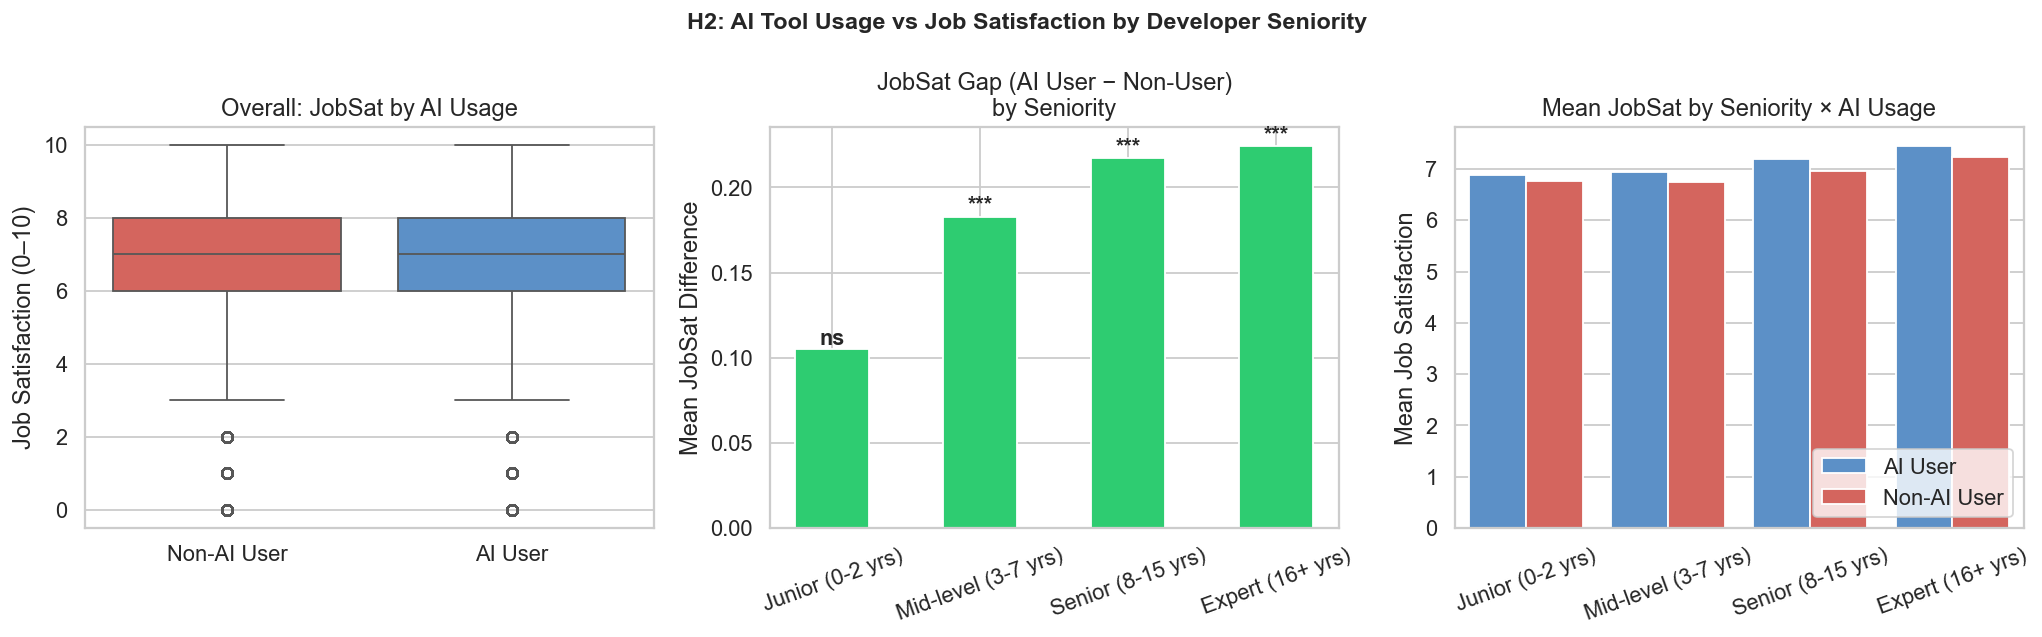

Saved to outputs/figures/H2_ai_satisfaction_plots.png


In [6]:
import os
os.makedirs('outputs/figures', exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('H2: AI Tool Usage vs Job Satisfaction by Developer Seniority',
             fontsize=13, fontweight='bold')

# ── Plot 1: Box plot overall ──────────────────────────────────────
h2_plot = h2.copy()
h2_plot['AI Usage'] = h2_plot['AIUser'].map({1.0: 'AI User', 0.0: 'Non-AI User'})

sns.boxplot(data=h2_plot, x='AI Usage', y='JobSat', hue='AI Usage',
            ax=axes[0], palette=['#E8534A', '#4A90D9'], legend=False)
axes[0].set_title('Overall: JobSat by AI Usage')
axes[0].set_ylabel('Job Satisfaction (0-10)')
axes[0].set_xlabel('')

# ── Plot 2: Gap bar chart by seniority ───────────────────────────
colors = ['#2ECC71' if g > 0 else '#E74C3C' for g in results_df['Gap']]
bars = axes[1].bar(results_df['Band'], results_df['Gap'],
                   color=colors, edgecolor='white', width=0.5)
axes[1].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('JobSat Gap (AI User − Non-User)\nby Seniority')
axes[1].set_ylabel('Mean JobSat Difference')
axes[1].tick_params(axis='x', rotation=20)
for bar, row in zip(bars, results_df.itertuples()):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.003,
                 row.sig, ha='center', fontsize=12, fontweight='bold')

# ── Plot 3: Grouped bar by seniority x AI usage ──────────────────
plot_data = h2_plot.groupby(['SeniorityBand', 'AI Usage'])['JobSat'].mean().reset_index()
sns.barplot(data=plot_data, x='SeniorityBand', y='JobSat',
            hue='AI Usage', ax=axes[2],
            palette={'AI User': '#4A90D9', 'Non-AI User': '#E8534A'},
            order=seniority_order)
axes[2].set_title('Mean JobSat by Seniority × AI Usage')
axes[2].set_ylabel('Mean Job Satisfaction')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=20)
axes[2].legend(title='', loc='lower right')

plt.tight_layout()
plt.savefig('outputs/figures/H2_ai_satisfaction_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/figures/H2_ai_satisfaction_plots.png")


## Step 5 — AI Sentiment vs Job Satisfaction (Spearman Correlation)

In [7]:
sent_map = {
    'Very unfavorable': 1, 'Unfavorable': 2, 'Indifferent': 3,
    'Favorable': 4, 'Very favorable': 5
}
h2['AISentNumeric'] = h2['AISent'].map(sent_map)
h2_sent_valid = h2[h2['AISentNumeric'].notna()]

corr, p_corr = stats.spearmanr(h2_sent_valid['AISentNumeric'], h2_sent_valid['JobSat'])
print(f"Spearman correlation (AISent vs JobSat): r = {corr:.3f}")
print(f"P-value                                : {p_corr:.6f}")
print(f"Significant at α=0.05                  : {'Yes' if p_corr < 0.05 else 'No'}")
print(f"Direction                              : {'Positive' if corr > 0 else 'Negative'} correlation")
print(f"\nInterpretation: Developers with more favorable AI sentiment tend to report "
      f"{'higher' if corr > 0 else 'lower'} job satisfaction.")


Spearman correlation (AISent vs JobSat): r = 0.073
P-value                                : 0.000000
Significant at α=0.05                  : Yes
Direction                              : Positive correlation

Interpretation: Developers with more favorable AI sentiment tend to report higher job satisfaction.


## Conclusions

### Key Findings
### Plot 1 — Overall JobSat by AI Usage:
Both groups look nearly identical in distribution — median around 7. The difference is small visually, which is important context.

### Plot 2 — The key finding for H2:
The gap actually increases with seniority, not shrinks. Junior developers show ns (not significant), but Senior and Expert developers show *** (highly significant). This contradicts my original hypothesis.

### Plot 3 — Mean JobSat by Seniority × AI Usage:
Confirms plot 2 — the bars are very close across all bands, but the gap widens slightly for Senior/Expert.

### Do We Accept or Reject H2?
> *We reject H2 as stated — the satisfaction gap between AI users and non-users does not shrink with seniority. Contrary to our hypothesis, senior and expert developers show the strongest and most statistically significant association between AI tool adoption and job satisfaction, suggesting experienced developers may extract more value from AI tools rather than less.*

### Limitations
- Self-reported data — respondents may over/under-report satisfaction
- Causality cannot be established — AI tool adoption and job satisfaction may both be driven by a third factor (e.g., company culture, compensation)
